In [8]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt


3408 articles
↓
UMAP → (3408,5)

↓
HDBSCAN
38 clusters
447 noise

↓
BERTopic
42 topics

### Vis from main

In [6]:
from main import run_pipeline
results = run_pipeline()


Batches: 100%|██████████| 107/107 [00:04<00:00, 22.70it/s]


(3408, 384)
[UMAP] Cluster projection : (3408, 5)
[UMAP] Viz projection     : (3408, 2)


In [7]:
results.keys()

dict_keys(['articles', 'docs', 'article_embeddings', 'aim_embedding', 'cluster_embeddings', 'cluster_labels', 'viz_embeddings', 'aim_viz', 'umap_model', 'hdbscan_model'])

In [5]:
viz = results["viz_embeddings"]
similarity_matrix = results["similarity_matrix"]
labels = results["cluster_labels"]
docs = results["docs"]
bertopic_model = results["bertopic_model"]

### Vis from dataloader and embedings

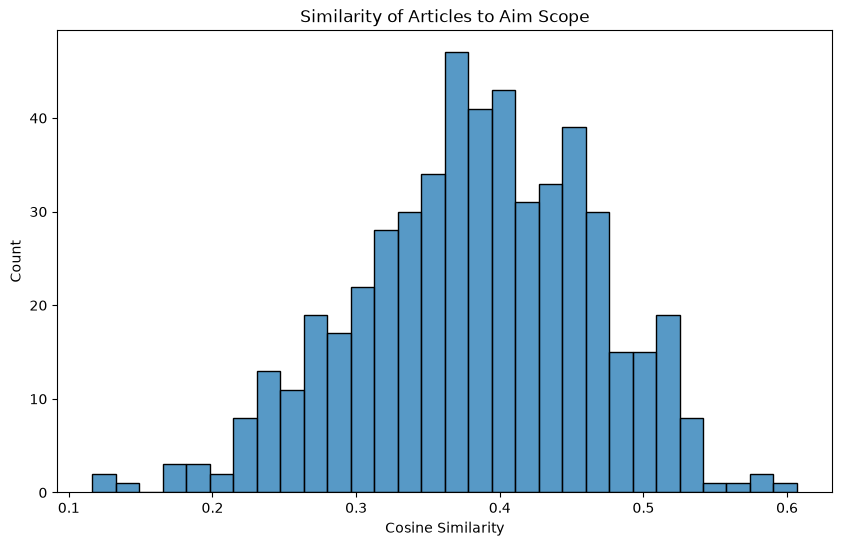

In [12]:
df = pd.read_csv("data/sampled_lancet_psychiatry_1000_preprcessing_skitlearn.csv")
sim = pd.read_csv("data/article_similarity_scores.csv")

plot_df = df.copy()
plot_df["similarity"] = sim["similarity_score"]

plt.figure(figsize=(10,6))
sns.histplot(data=plot_df, x="similarity", bins=30)

plt.title("Similarity of Articles to Aim Scope")
plt.xlabel("Cosine Similarity")
plt.ylabel("Count")

plt.show()

### INTERACTIVE CLUSTERING

In [13]:
import plotly.express as px

In [ ]:
plot_df = pd.DataFrame({
    "x": viz_embeddings[:,0],
    "y": viz_embeddings[:,1],
    "cluster": cluster_labels,
    "title": df["title"]
})

fig = px.scatter(
    plot_df,
    x="x",
    y="y",
    color="cluster",
    hover_data=["title"]
)

fig.show()

### BERTopic buildin visualization tools

In [14]:
from bertopic import BERTopic

In [ ]:
topic_model.visualize_topics()
topic_model.visualize_hierarchy()
topic_model.visualize_heatmap()